# 📊 09 — Full Comparison Report: SAHI vs No-SAHI × YOLO26m vs Custom

This notebook loads all evaluation results and produces a **comprehensive 4-way comparison**:

| # | Variant | Inference Method |
|---|---------|------------------|
| 1 | YOLO26m + SAHI | Sliding window 640×640, NMS merge |
| 2 | Custom + SAHI | Sliding window 640×640, NMS merge |
| 3 | YOLO26m + No SAHI | Direct `model.predict()` at imgsz=640 |
| 4 | Custom + No SAHI | Direct `model.predict()` at imgsz=640 |

### Outputs
- Full metrics comparison table
- SAHI impact analysis (how much SAHI helps each model)
- Multi-panel dashboard saved to `outputs/full_comparison_report.png`

In [1]:
# ============================================================
#  Imports
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "figure.dpi": 150,
})

print("Imports complete ✓")

Imports complete ✓


In [2]:
# ============================================================
#  Load all result files
# ============================================================

PROJECT_ROOT = Path("..")
METRICS_DIR  = PROJECT_ROOT / "outputs" / "metrics"
OUTPUT_DIR   = PROJECT_ROOT / "outputs"

# Expected result files from notebooks 03, 05, 07
result_files = {
    "YOLO26m + SAHI":    METRICS_DIR / "results.json",
    "Custom + SAHI":     METRICS_DIR / "results_custom.json",
    "YOLO26m (No SAHI)": METRICS_DIR / "results_yolo26m_no_sahi.json",
    "Custom (No SAHI)":  METRICS_DIR / "results_custom_no_sahi.json",
}

all_results = {}
missing = []

for name, path in result_files.items():
    if path.exists():
        with open(path) as f:
            data = json.load(f)
        all_results[name] = data
        print(f"  ✅ {name:<25} → {path.name}")
    else:
        missing.append(name)
        print(f"  ❌ {name:<25} → NOT FOUND ({path.name})")

if missing:
    print(f"\n⚠️  Missing {len(missing)} result file(s). Run the corresponding notebooks first:")
    print(f"   • SAHI results:    Run 03_inference.ipynb and 05_compare_models.ipynb")
    print(f"   • No-SAHI results: Run 07_compare_no_sahi.ipynb")
else:
    print(f"\n✅ All 4 result files loaded.")

  ✅ YOLO26m + SAHI            → results.json
  ✅ Custom + SAHI             → results_custom.json
  ✅ YOLO26m (No SAHI)         → results_yolo26m_no_sahi.json
  ✅ Custom (No SAHI)          → results_custom_no_sahi.json

✅ All 4 result files loaded.


## 📋 Full Metrics Comparison Table

In [3]:
# ============================================================
#  Build comparison table
# ============================================================

rows = []
for name in result_files.keys():
    if name not in all_results:
        continue
    s = all_results[name]["summary"]
    rows.append({
        "Variant": name,
        "mAP@50": s["mAP50"],
        "Precision": s["precision"],
        "Recall": s["recall"],
        "TP": s["total_true_positives"],
        "FP": s["total_false_positives"],
        "GT": s["total_ground_truth"],
        "Avg Time (s)": s["avg_inference_time_sec"],
    })

df = pd.DataFrame(rows)

# Highlight best values
print("\n" + "=" * 100)
print("  📊 FULL 4-WAY COMPARISON — Test Set")
print("=" * 100)
print(df.to_string(index=False))
print("=" * 100)

# Find overall best
best_idx = df["mAP@50"].idxmax()
best_variant = df.loc[best_idx, "Variant"]
best_map = df.loc[best_idx, "mAP@50"]
print(f"\n🏆 Best overall mAP@50: {best_variant} ({best_map:.4f})")

# Fastest
fast_idx = df["Avg Time (s)"].idxmin()
print(f"⚡ Fastest inference:   {df.loc[fast_idx, 'Variant']} ({df.loc[fast_idx, 'Avg Time (s)']:.3f}s)")


  📊 FULL 4-WAY COMPARISON — Test Set
          Variant  mAP@50  Precision  Recall    TP    FP    GT  Avg Time (s)
   YOLO26m + SAHI  0.5562     0.6297  0.6844 22571 13274 32980         0.820
    Custom + SAHI  0.2845     0.5218  0.3780 12465 11422 32980         0.710
YOLO26m (No SAHI)  0.4356     0.6121  0.4142 13659  8655 32980         0.101
 Custom (No SAHI)  0.2416     0.6873  0.2214  7301  3321 32980         0.094

🏆 Best overall mAP@50: YOLO26m + SAHI (0.5562)
⚡ Fastest inference:   Custom (No SAHI) (0.094s)


## 🔬 SAHI Impact Analysis

How much does SAHI improve each model?

In [4]:
# ============================================================
#  SAHI Impact: compare SAHI vs No-SAHI for each model
# ============================================================

impact_rows = []

pairs = [
    ("YOLO26m", "YOLO26m + SAHI", "YOLO26m (No SAHI)"),
    ("Custom",  "Custom + SAHI",  "Custom (No SAHI)"),
]

for model_name, sahi_key, nosahi_key in pairs:
    if sahi_key in all_results and nosahi_key in all_results:
        s_sahi   = all_results[sahi_key]["summary"]
        s_nosahi = all_results[nosahi_key]["summary"]
        
        d_map  = s_sahi["mAP50"]     - s_nosahi["mAP50"]
        d_prec = s_sahi["precision"] - s_nosahi["precision"]
        d_rec  = s_sahi["recall"]    - s_nosahi["recall"]
        d_time = s_sahi["avg_inference_time_sec"] - s_nosahi["avg_inference_time_sec"]
        
        pct_map = (d_map / max(0.0001, s_nosahi["mAP50"])) * 100
        
        impact_rows.append({
            "Model": model_name,
            "mAP@50 (SAHI)": f"{s_sahi['mAP50']:.4f}",
            "mAP@50 (No SAHI)": f"{s_nosahi['mAP50']:.4f}",
            "Δ mAP@50": f"{d_map:+.4f}",
            "% Gain": f"{pct_map:+.1f}%",
            "Δ Precision": f"{d_prec:+.4f}",
            "Δ Recall": f"{d_rec:+.4f}",
            "Δ Time (s)": f"{d_time:+.2f}",
        })

if impact_rows:
    impact_df = pd.DataFrame(impact_rows)
    print("\n" + "=" * 110)
    print("  🔬 SAHI IMPACT — How much does sliced inference help?")
    print("=" * 110)
    print(impact_df.to_string(index=False))
    print("=" * 110)
else:
    print("⚠️ Need both SAHI and No-SAHI results for at least one model.")


  🔬 SAHI IMPACT — How much does sliced inference help?
  Model mAP@50 (SAHI) mAP@50 (No SAHI) Δ mAP@50 % Gain Δ Precision Δ Recall Δ Time (s)
YOLO26m        0.5562           0.4356  +0.1206 +27.7%     +0.0176  +0.2702      +0.72
 Custom        0.2845           0.2416  +0.0429 +17.8%     -0.1655  +0.1566      +0.62


## 📊 Visual Dashboard

/tmp/ipykernel_850740/1580145822.py:163: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Liberation Sans.
  fig.savefig(save_path, dpi=200, bbox_inches="tight",
/home/rakib/miniconda3/envs/yolo/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


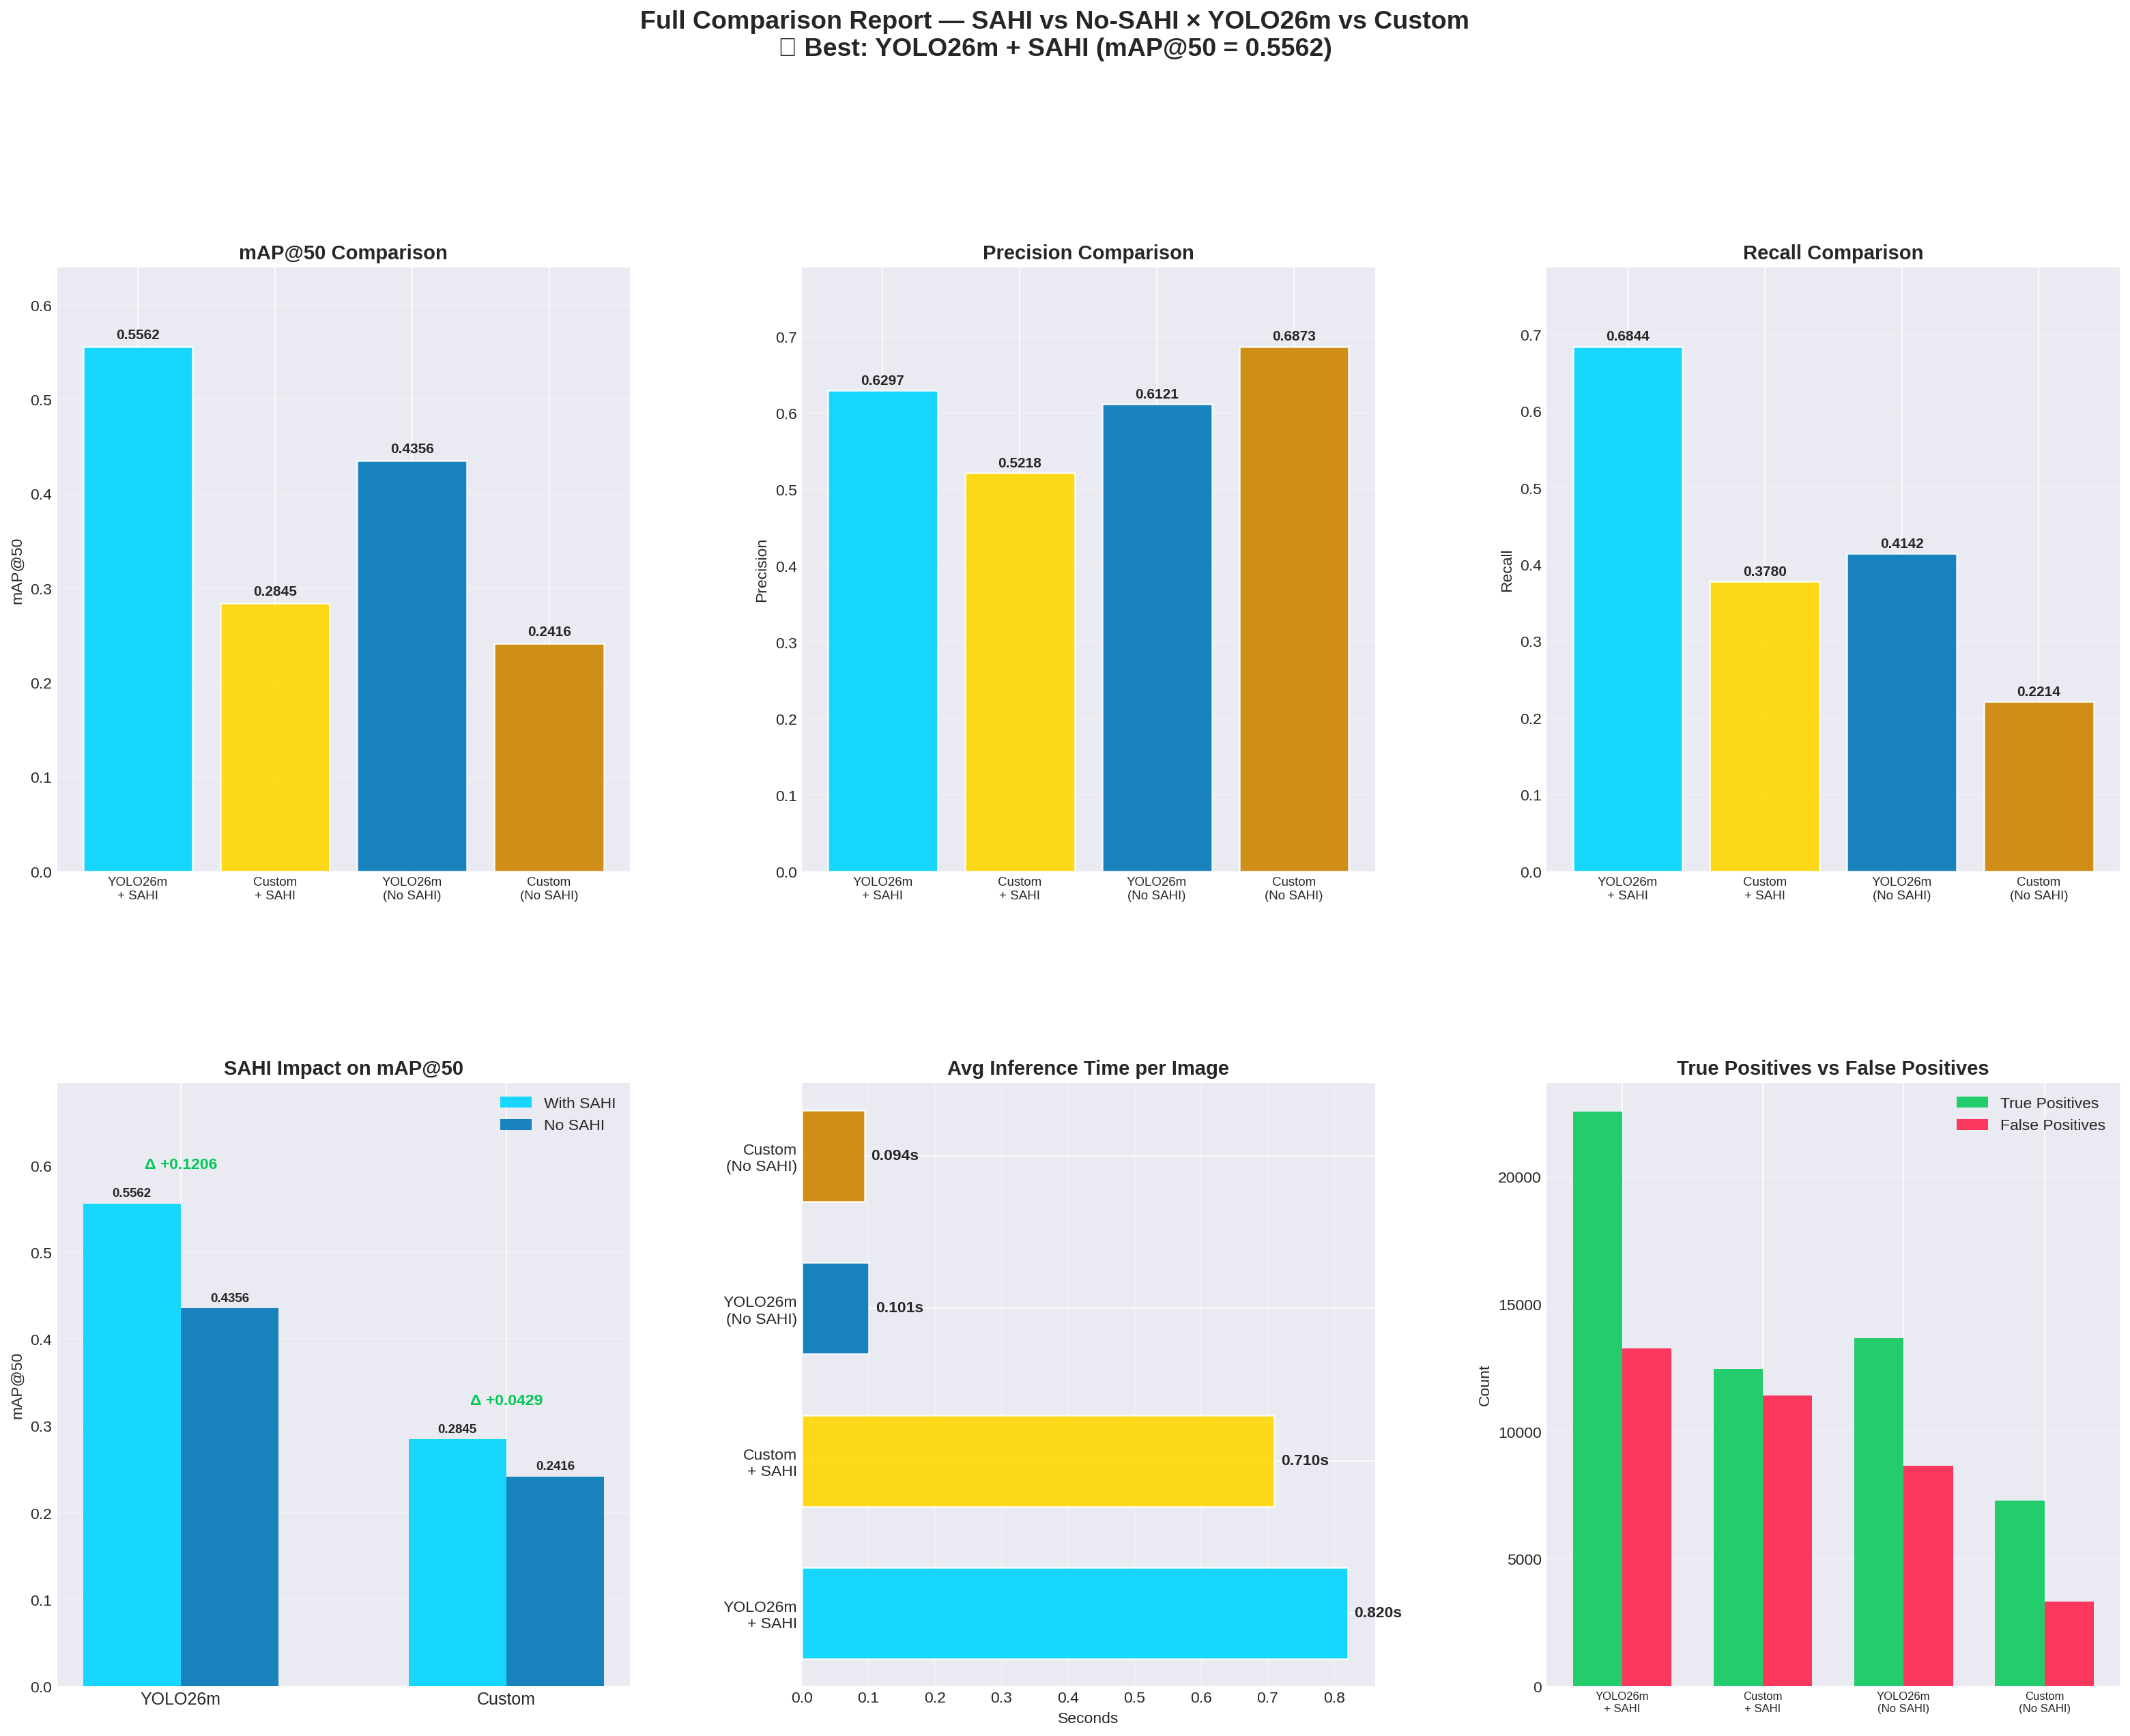


✅ Dashboard saved to: /home/rakib/Desktop/OFFICE/Projects/ALL Products/outputs/full_comparison_report.png


In [5]:
# ============================================================
#  4-Way Comparison Dashboard
# ============================================================

# Colors for each variant
COLORS = {
    "YOLO26m + SAHI":    "#00D4FF",   # Bright cyan
    "Custom + SAHI":     "#FFD700",   # Gold
    "YOLO26m (No SAHI)": "#0077B6",   # Dark blue
    "Custom (No SAHI)":  "#CC8400",   # Dark gold
}

variants = [v for v in result_files.keys() if v in all_results]
n_vars = len(variants)

fig = plt.figure(figsize=(26, 18))
gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.30)

# ----------------------------------------------------------
#  1. mAP@50 Bar Chart
# ----------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
map_vals = [all_results[v]["summary"]["mAP50"] for v in variants]
bars = ax1.bar(range(n_vars), map_vals,
               color=[COLORS[v] for v in variants],
               alpha=0.90, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, map_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax1.set_xticks(range(n_vars))
ax1.set_xticklabels([v.replace(' + ', '\n+ ').replace(' (', '\n(') for v in variants],
                     fontsize=9)
ax1.set_ylim(0, max(map_vals) * 1.15)
ax1.set_ylabel("mAP@50")
ax1.set_title("mAP@50 Comparison")
ax1.grid(True, alpha=0.3, axis="y")

# ----------------------------------------------------------
#  2. Precision Bar Chart
# ----------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
prec_vals = [all_results[v]["summary"]["precision"] for v in variants]
bars = ax2.bar(range(n_vars), prec_vals,
               color=[COLORS[v] for v in variants],
               alpha=0.90, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, prec_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax2.set_xticks(range(n_vars))
ax2.set_xticklabels([v.replace(' + ', '\n+ ').replace(' (', '\n(') for v in variants],
                     fontsize=9)
ax2.set_ylim(0, max(prec_vals) * 1.15)
ax2.set_ylabel("Precision")
ax2.set_title("Precision Comparison")
ax2.grid(True, alpha=0.3, axis="y")

# ----------------------------------------------------------
#  3. Recall Bar Chart
# ----------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
rec_vals = [all_results[v]["summary"]["recall"] for v in variants]
bars = ax3.bar(range(n_vars), rec_vals,
               color=[COLORS[v] for v in variants],
               alpha=0.90, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, rec_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax3.set_xticks(range(n_vars))
ax3.set_xticklabels([v.replace(' + ', '\n+ ').replace(' (', '\n(') for v in variants],
                     fontsize=9)
ax3.set_ylim(0, max(rec_vals) * 1.15)
ax3.set_ylabel("Recall")
ax3.set_title("Recall Comparison")
ax3.grid(True, alpha=0.3, axis="y")

# ----------------------------------------------------------
#  4. SAHI Impact (grouped bar: SAHI vs No-SAHI)
# ----------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 0])
models = ["YOLO26m", "Custom"]
sahi_map, nosahi_map = [], []
for m in models:
    sk = f"{m} + SAHI"
    nk = f"{m} (No SAHI)"
    sahi_map.append(all_results[sk]["summary"]["mAP50"] if sk in all_results else 0)
    nosahi_map.append(all_results[nk]["summary"]["mAP50"] if nk in all_results else 0)

x = np.arange(len(models))
bw = 0.30
b1 = ax4.bar(x - bw/2, sahi_map, bw, label="With SAHI", color="#00D4FF", alpha=0.9)
b2 = ax4.bar(x + bw/2, nosahi_map, bw, label="No SAHI", color="#0077B6", alpha=0.9)
for b in b1:
    ax4.text(b.get_x()+b.get_width()/2, b.get_height()+0.008,
             f"{b.get_height():.4f}", ha="center", fontsize=9, fontweight="bold")
for b in b2:
    ax4.text(b.get_x()+b.get_width()/2, b.get_height()+0.008,
             f"{b.get_height():.4f}", ha="center", fontsize=9, fontweight="bold")

# Draw delta arrows
for i in range(len(models)):
    delta = sahi_map[i] - nosahi_map[i]
    mid_x = x[i]
    mid_y = max(sahi_map[i], nosahi_map[i]) + 0.04
    color = "#00C853" if delta > 0 else "#F44336"
    ax4.text(mid_x, mid_y, f"Δ {delta:+.4f}", ha="center",
             fontsize=11, fontweight="bold", color=color)

ax4.set_xticks(x)
ax4.set_xticklabels(models, fontsize=12)
ax4.set_ylim(0, max(sahi_map + nosahi_map) * 1.25)
ax4.set_ylabel("mAP@50")
ax4.set_title("SAHI Impact on mAP@50")
ax4.legend(framealpha=0.9)
ax4.grid(True, alpha=0.3, axis="y")

# ----------------------------------------------------------
#  5. Inference Speed Comparison
# ----------------------------------------------------------
ax5 = fig.add_subplot(gs[1, 1])
time_vals = [all_results[v]["summary"]["avg_inference_time_sec"] for v in variants]
short_names = [v.replace(' + ', '\n+ ').replace(' (', '\n(') for v in variants]
bars = ax5.barh(short_names, time_vals,
                color=[COLORS[v] for v in variants],
                alpha=0.9, edgecolor="white", linewidth=1.2, height=0.6)
for bar, val in zip(bars, time_vals):
    ax5.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}s", va="center", fontsize=11, fontweight="bold")
ax5.set_title("Avg Inference Time per Image")
ax5.set_xlabel("Seconds")
ax5.grid(True, alpha=0.3, axis="x")

# ----------------------------------------------------------
#  6. TP / FP Grouped Comparison
# ----------------------------------------------------------
ax6 = fig.add_subplot(gs[1, 2])
tp_vals = [all_results[v]["summary"]["total_true_positives"] for v in variants]
fp_vals = [all_results[v]["summary"]["total_false_positives"] for v in variants]

x6 = np.arange(n_vars)
bw6 = 0.35
ax6.bar(x6 - bw6/2, tp_vals, bw6, label="True Positives", color="#00C853", alpha=0.85)
ax6.bar(x6 + bw6/2, fp_vals, bw6, label="False Positives", color="#FF1744", alpha=0.85)
ax6.set_xticks(x6)
ax6.set_xticklabels([v.replace(' + ', '\n+ ').replace(' (', '\n(') for v in variants],
                     fontsize=8)
ax6.set_ylabel("Count")
ax6.set_title("True Positives vs False Positives")
ax6.legend(framealpha=0.9)
ax6.grid(True, alpha=0.3, axis="y")

# ----------------------------------------------------------
#  Suptitle
# ----------------------------------------------------------
best_name = variants[np.argmax(map_vals)]
best_v = max(map_vals)
fig.suptitle(
    f"Full Comparison Report — SAHI vs No-SAHI × YOLO26m vs Custom\n"
    f"🏆 Best: {best_name} (mAP@50 = {best_v:.4f})",
    fontsize=18, fontweight="bold", y=1.02,
)

save_path = OUTPUT_DIR / "full_comparison_report.png"
fig.savefig(save_path, dpi=200, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()

print(f"\n✅ Dashboard saved to: {save_path.resolve()}")

## 📋 Per-Image SAHI Impact Scatter

/tmp/ipykernel_850740/737443912.py:56: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_850740/737443912.py:56: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_850740/737443912.py:56: UserWarning: Glyph 9898 (\N{MEDIUM WHITE CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_850740/737443912.py:59: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Liberation Sans.
  fig.savefig(scatter_path, dpi=200, bbox_inches="tight",
/tmp/ipykernel_850740/737443912.py:59: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  fig.savefig(scatter_path, dpi=200, bbox_inches="tight",
/tmp/ipykernel_850740/737443912.py:59: UserWarning: Glyph 9898 (\N{MEDIUM WHITE CIRCLE}) missing from font(s) Liberation Sans.
  fig.savefig(scatter_path, dpi=200, bbox_inches="tight",
/

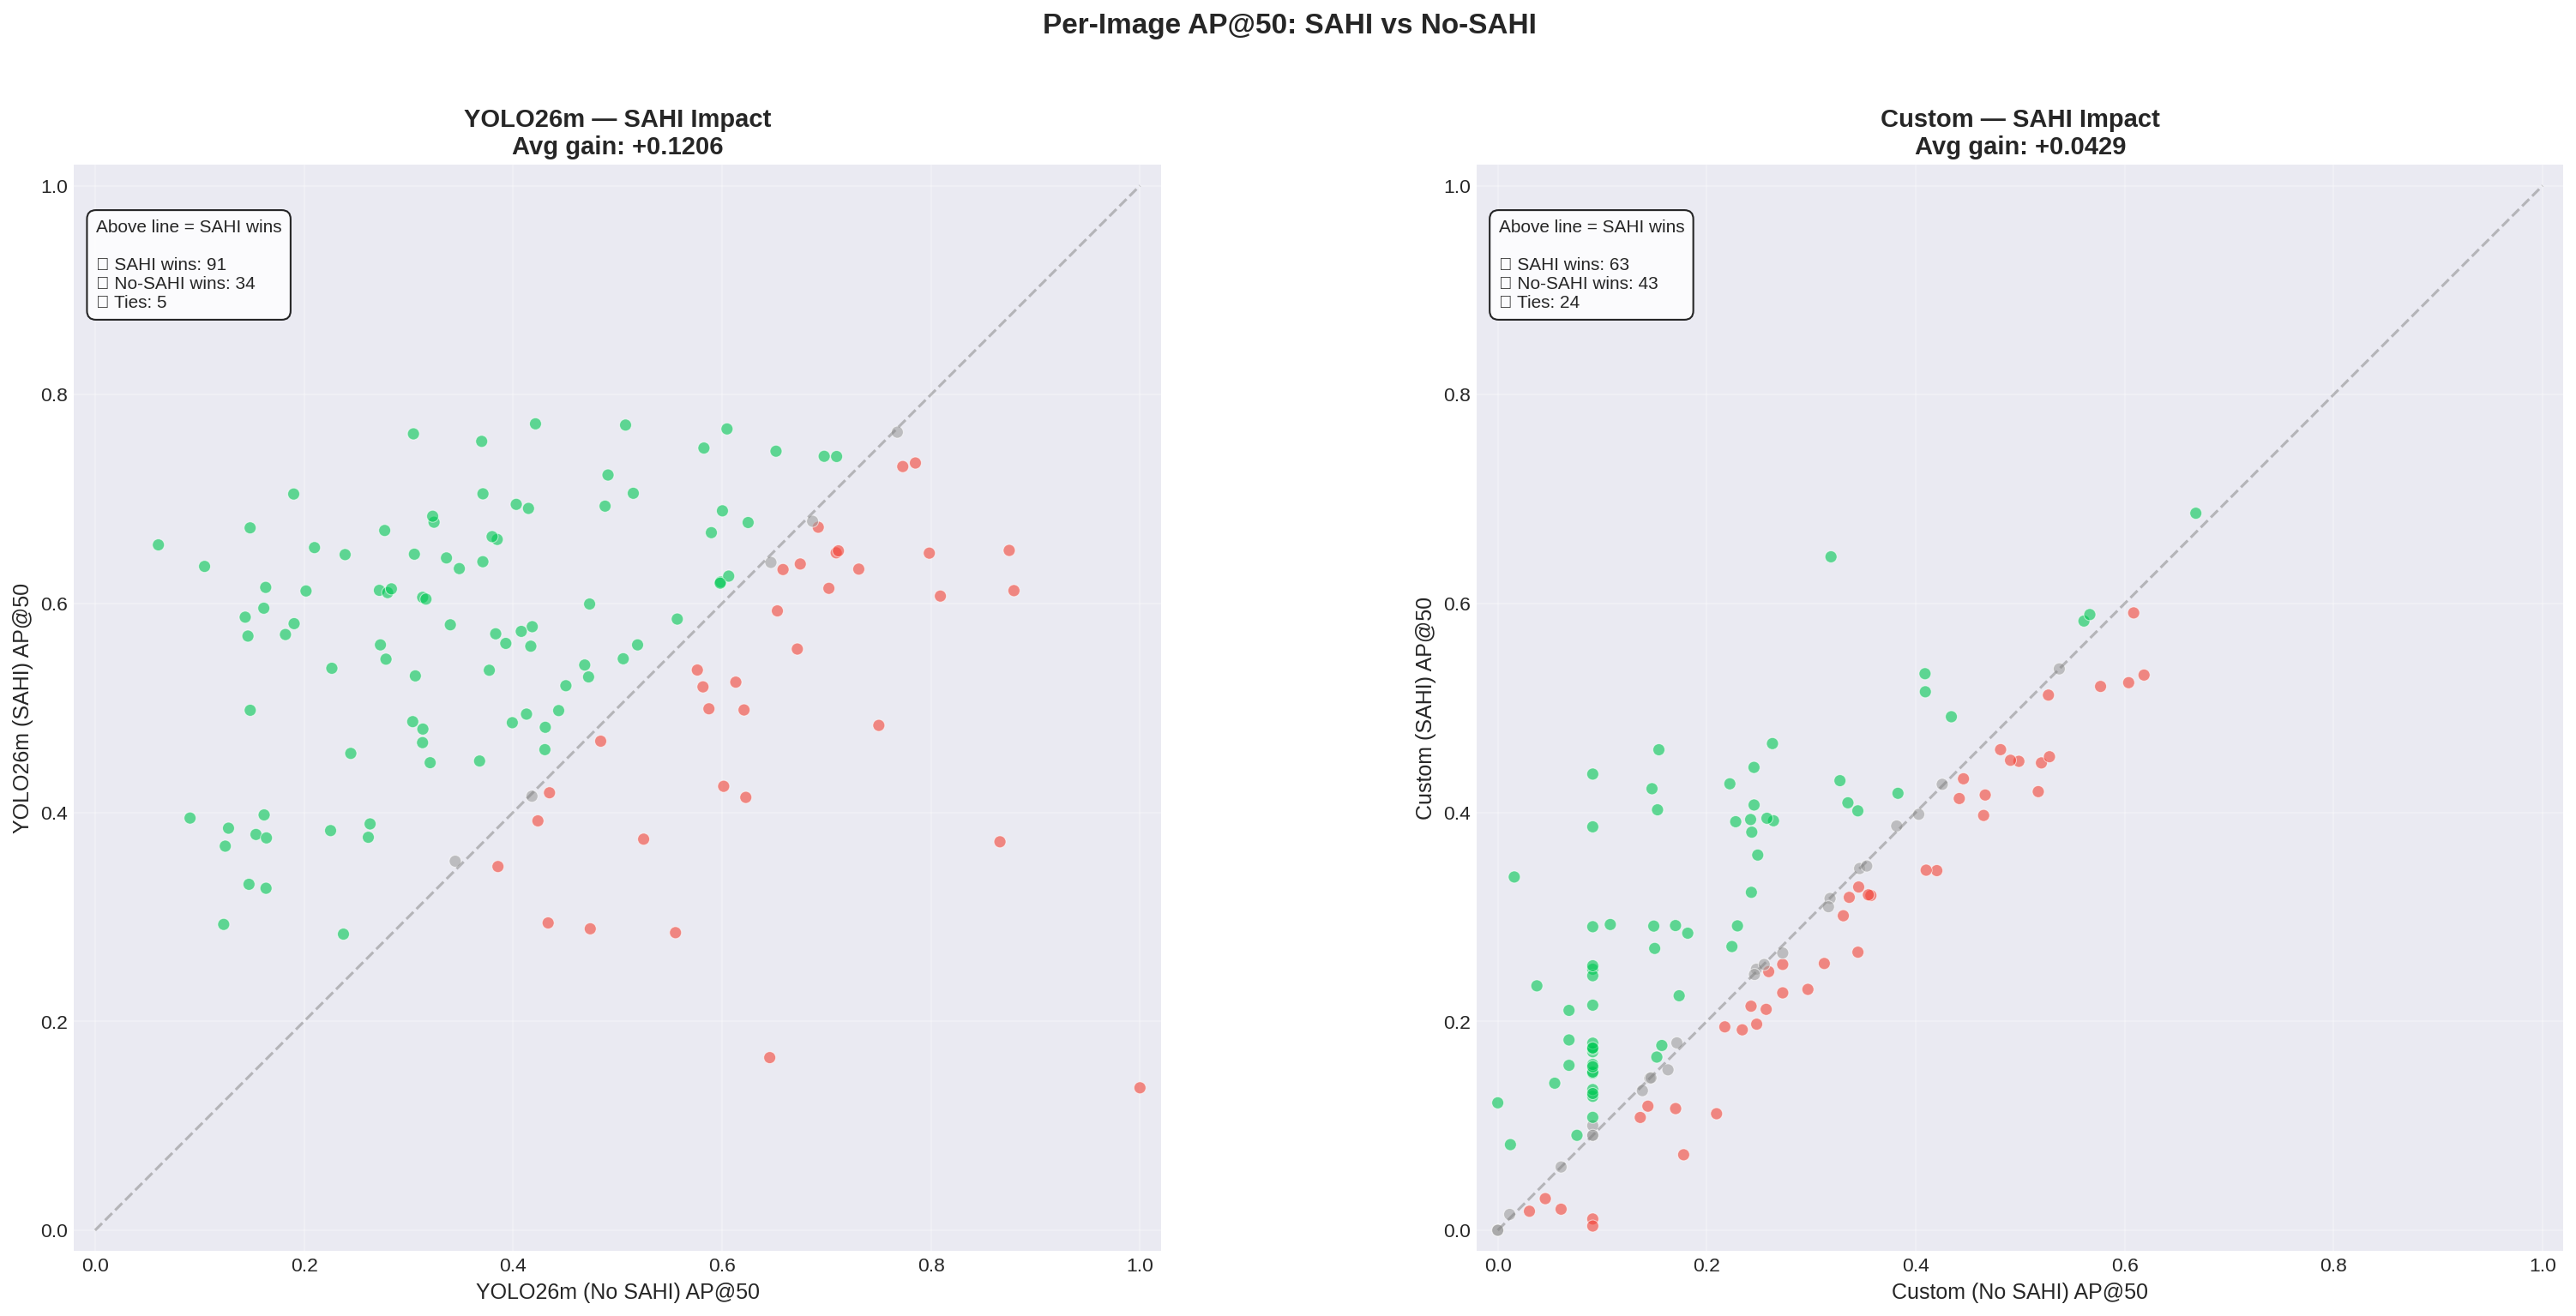

✅ Saved to: /home/rakib/Desktop/OFFICE/Projects/ALL Products/outputs/sahi_impact_scatter.png


In [6]:
# ============================================================
#  Per-image scatter: SAHI vs No-SAHI for each model
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

pairs_plot = [
    ("YOLO26m", "YOLO26m + SAHI", "YOLO26m (No SAHI)", "#00D4FF"),
    ("Custom",  "Custom + SAHI",  "Custom (No SAHI)",  "#FFD700"),
]

for ax, (model_name, sahi_key, nosahi_key, color) in zip(axes, pairs_plot):
    if sahi_key not in all_results or nosahi_key not in all_results:
        ax.text(0.5, 0.5, f"Missing data for {model_name}",
                ha="center", va="center", fontsize=14)
        ax.set_title(model_name)
        continue
    
    sahi_per   = {r["image"]: r["ap50"] for r in all_results[sahi_key]["per_image"]}
    nosahi_per = {r["image"]: r["ap50"] for r in all_results[nosahi_key]["per_image"]}
    
    common = sorted(set(sahi_per.keys()) & set(nosahi_per.keys()))
    sahi_ap   = np.array([sahi_per[k] for k in common])
    nosahi_ap = np.array([nosahi_per[k] for k in common])
    
    # Color by which is better
    c = ["#00C853" if s > n + 0.01 else "#F44336" if n > s + 0.01 else "#9E9E9E"
         for s, n in zip(sahi_ap, nosahi_ap)]
    
    ax.scatter(nosahi_ap, sahi_ap, c=c, alpha=0.6, s=45, edgecolors="white", linewidth=0.5)
    ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
    
    ax.set_xlabel(f"{model_name} (No SAHI) AP@50", fontsize=12)
    ax.set_ylabel(f"{model_name} (SAHI) AP@50", fontsize=12)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_aspect("equal")
    
    sahi_wins   = np.sum(sahi_ap > nosahi_ap + 0.01)
    nosahi_wins = np.sum(nosahi_ap > sahi_ap + 0.01)
    ties = len(common) - sahi_wins - nosahi_wins
    avg_gain = np.mean(sahi_ap - nosahi_ap)
    
    ax.set_title(f"{model_name} — SAHI Impact\n"
                 f"Avg gain: {avg_gain:+.4f}")
    ax.text(0.02, 0.95,
            f"Above line = SAHI wins\n\n"
            f"🟢 SAHI wins: {sahi_wins}\n"
            f"🔴 No-SAHI wins: {nosahi_wins}\n"
            f"⚪ Ties: {ties}",
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85))
    ax.grid(True, alpha=0.3)

plt.suptitle("Per-Image AP@50: SAHI vs No-SAHI",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()

scatter_path = OUTPUT_DIR / "sahi_impact_scatter.png"
fig.savefig(scatter_path, dpi=200, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()

print(f"✅ Saved to: {scatter_path.resolve()}")

## 📝 Final Summary Report

In [7]:
# ============================================================
#  Print final comprehensive summary
# ============================================================

print("\n" + "█" * 80)
print("█" + " " * 78 + "█")
print("█" + "  FULL COMPARISON REPORT".center(78) + "█")
print("█" + "  Dense Retail Shelf Detection — YOLO26m vs Custom".center(78) + "█")
print("█" + " " * 78 + "█")
print("█" * 80)

print(f"\n{'─'*80}")
print(f"  {'Variant':<25} {'mAP@50':>10} {'Prec':>10} {'Recall':>10} {'Time(s)':>10}")
print(f"{'─'*80}")
for v in variants:
    s = all_results[v]["summary"]
    tag = "  🏆" if v == best_name else ""
    print(f"  {v:<25} {s['mAP50']:>10.4f} {s['precision']:>10.4f} "
          f"{s['recall']:>10.4f} {s['avg_inference_time_sec']:>10.3f}{tag}")
print(f"{'─'*80}")

print(f"\n  📈 SAHI Impact:")
for model_name, sahi_key, nosahi_key in pairs:
    if sahi_key in all_results and nosahi_key in all_results:
        d = all_results[sahi_key]["summary"]["mAP50"] - all_results[nosahi_key]["summary"]["mAP50"]
        pct = (d / max(0.0001, all_results[nosahi_key]["summary"]["mAP50"])) * 100
        emoji = "📈" if d > 0 else "📉"
        print(f"     {emoji} {model_name}: SAHI gives {d:+.4f} mAP@50 ({pct:+.1f}%)")

print(f"\n  📁 Output Files:")
print(f"     {(OUTPUT_DIR / 'full_comparison_report.png').resolve()}")
print(f"     {(OUTPUT_DIR / 'sahi_impact_scatter.png').resolve()}")
for name, path in result_files.items():
    if path.exists():
        print(f"     {path.resolve()}")


████████████████████████████████████████████████████████████████████████████████
█                                                                              █
█                             FULL COMPARISON REPORT                           █
█                Dense Retail Shelf Detection — YOLO26m vs Custom              █
█                                                                              █
████████████████████████████████████████████████████████████████████████████████

────────────────────────────────────────────────────────────────────────────────
  Variant                       mAP@50       Prec     Recall    Time(s)
────────────────────────────────────────────────────────────────────────────────
  YOLO26m + SAHI                0.5562     0.6297     0.6844      0.820  🏆
  Custom + SAHI                 0.2845     0.5218     0.3780      0.710
  YOLO26m (No SAHI)             0.4356     0.6121     0.4142      0.101
  Custom (No SAHI)              0.2416     0.6873     0.221